In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/infoseccyber-security-salaries/Cyber_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,DE,100,DE,S
1,2022,SE,FT,Security Officer,123400,USD,123400,US,0,US,M
2,2022,SE,FT,Security Officer,88100,USD,88100,US,0,US,M
3,2022,SE,FT,Security Engineer,163575,USD,163575,US,100,US,M
4,2022,SE,FT,Security Engineer,115800,USD,115800,US,100,US,M


# Understanding Cyber salaries Data

In [3]:
df.shape

(1349, 11)

Cyber Salaries dataset has 1349 samples (rows) and 11 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           1349 non-null   int64 
 1   experience_level    1349 non-null   object
 2   employment_type     1349 non-null   object
 3   job_title           1349 non-null   object
 4   salary              1349 non-null   int64 
 5   salary_currency     1349 non-null   object
 6   salary_in_usd       1349 non-null   int64 
 7   employee_residence  1349 non-null   object
 8   remote_ratio        1349 non-null   int64 
 9   company_location    1349 non-null   object
 10  company_size        1349 non-null   object
dtypes: int64(4), object(7)
memory usage: 116.1+ KB


The Cyber Salaries dataset comprises four integer (int64) columns and seven object (string) columns. Additionally, the dataset contains no missing values, as all columns have identical record counts.

In [5]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,1349.000000,1.349000e+03,1349.000000,1349.000000
mean,2021.368421,5.288248e+05,121578.622683,72.238695
std,0.711236,1.361367e+07,68972.954838,39.355331
min,2020.000000,1.740000e+03,2000.000000,0.000000
25%,2021.000000,8.000000e+04,75000.000000,50.000000
50%,2022.000000,1.200000e+05,115000.000000,100.000000
75%,2022.000000,1.600800e+05,152000.000000,100.000000
max,2022.000000,5.000000e+08,899920.000000,100.000000


From the above statistical summary, we can draw sum insights:
- Minimum Cyber Security Salary is 2000 USD
- Maximum Cyber Security Salary is 899920 USD
- This dataset is based from 2020 to 2022

In [6]:
df.describe(include='all')

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,1349.000000,1349,1349,1349,1.349000e+03,1349,1349.000000,1349,1349.000000,1349,1349
unique,NaN,4,4,87,NaN,21,NaN,60,NaN,57,3
top,NaN,SE,FT,Security Engineer,NaN,USD,NaN,US,NaN,US,L
freq,NaN,622,1326,247,NaN,1026,NaN,940,NaN,965,798
mean,2021.368421,NaN,NaN,NaN,5.288248e+05,NaN,121578.622683,NaN,72.238695,NaN,NaN
std,0.711236,NaN,NaN,NaN,1.361367e+07,NaN,68972.954838,NaN,39.355331,NaN,NaN
min,2020.000000,NaN,NaN,NaN,1.740000e+03,NaN,2000.000000,NaN,0.000000,NaN,NaN
25%,2021.000000,NaN,NaN,NaN,8.000000e+04,NaN,75000.000000,NaN,50.000000,NaN,NaN
50%,2022.000000,NaN,NaN,NaN,1.200000e+05,NaN,115000.000000,NaN,100.000000,NaN,NaN
75%,2022.000000,NaN,NaN,NaN,1.600800e+05,NaN,152000.000000,NaN,100.000000,NaN,NaN


Other Insight

- In the cybersecurity field, the majority of professionals are employed in the role of Security Engineer. However, this observation cannot be generalized across all countries, as 64% (860 samples) of the cybersecurity salaries dataset originates from the United States.

In [7]:
unique_job_titles = df['job_title'].unique()
company_location = df['company_location'].unique()

print(f"Total unique job titles: {len(unique_job_titles)}")
print(f"Total Company locations: {len(company_location)}")

Total unique job titles: 87
Total Company locations: 57


Cyber Salaries dataset has 87 unique job titles from 57 countries around the world. This demonstrate a broad range of specialization areas within the security domain and providing valuable insight for security professionals when identifying or selecting areas of focus.

# Exploratory Data Analysis (EDA)

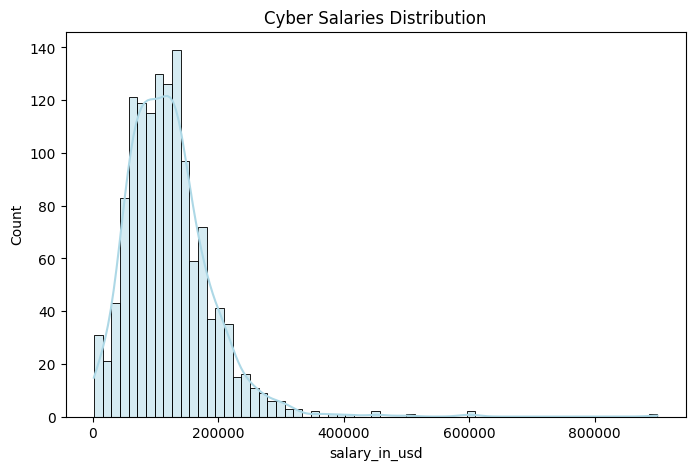

In [8]:
# Let’s see how Salary in USD is distributed.

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='salary_in_usd', kde=True, color='lightblue')
plt.title("Cyber Salaries Distribution")
plt.show()

The *salary_in_usd* distribution is right-skewed, meaning the mean is greater than the median due to the long tail on the higher end. Most salaries are clustered at the lower end, with relatively few high-value salaries stretching the right tail.

<h3>Does company size impact the salary of a cybersecurity employee?</h3>

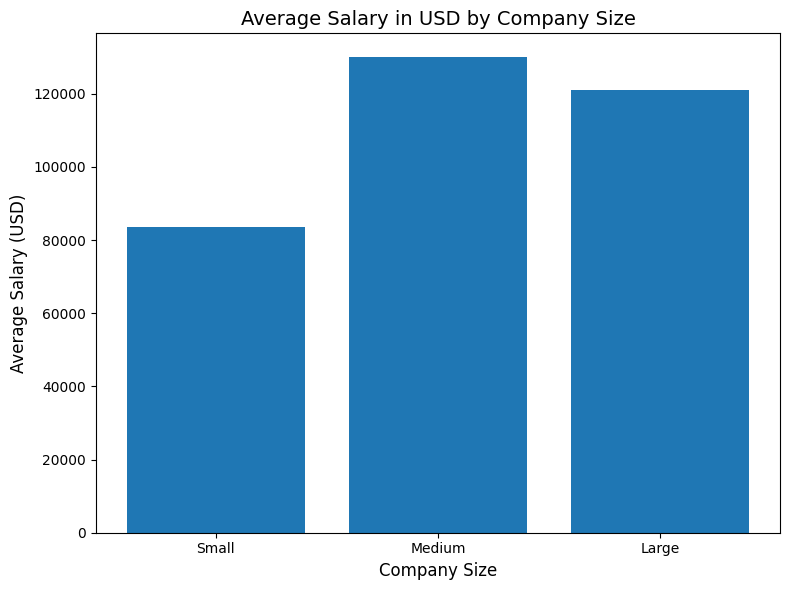

In [9]:
size_labels = {"S": "Small", "M": "Medium", "L": "Large"}

avg_size = (df.groupby("company_size")["salary_in_usd"].mean().reset_index())

avg_size["company_size"] = (avg_size["company_size"].map(size_labels))

order = ["Small", "Medium", "Large"]
avg_size["company_size"] = pd.Categorical(avg_size["company_size"], categories=order, ordered=True)
avg_size = avg_size.sort_values("company_size")

plt.figure(figsize=(8, 6))
plt.bar(avg_size["company_size"], avg_size["salary_in_usd"])
plt.title("Average Salary in USD by Company Size", fontsize=14)
plt.xlabel("Company Size", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
avg_size

,company_size,salary_in_usd
2,Small,83625.228261
1,Medium,130029.505447
0,Large,121093.355890


The analysis above suggests that company size alone cannot determine whether an individual will receive higher or lower pay. Due to the average salary from company size, people employed in medium-sized companies may be more likely to receive higher pay than those in large and small companies, but this is an analysis based on the collected data.

<h3>Does level of experience impact the salary of cybersecurity employee?</h3>

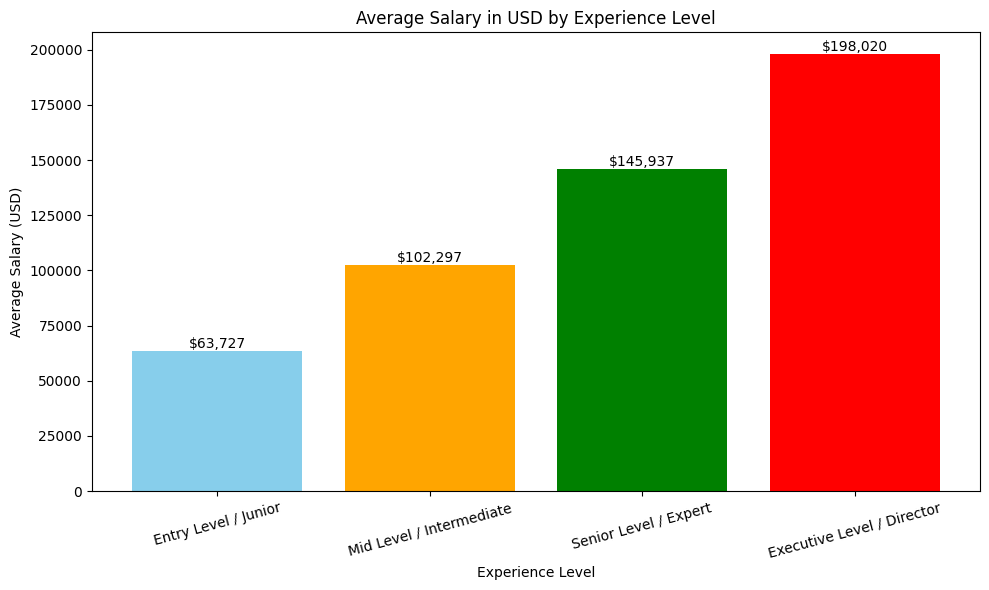

In [11]:
exp_label = {"EN": "Entry Level / Junior","MI": "Mid Level / Intermediate","SE": "Senior Level / Expert","EX": "Executive Level / Director"}

avg_level = (df.groupby("experience_level")["salary_in_usd"].mean().reset_index())

avg_level["experience_level"] = (avg_level["experience_level"].map(exp_label))

order = ["Entry Level / Junior","Mid Level / Intermediate","Senior Level / Expert","Executive Level / Director"]

avg_level["experience_level"] = pd.Categorical(avg_level["experience_level"],categories=order,ordered=True)
avg_level = avg_level.sort_values("experience_level")

colors = ["skyblue", "orange", "green", "red"]

plt.figure(figsize=(10, 6))
plt.bar(avg_level["experience_level"], avg_level["salary_in_usd"], color=colors)
plt.title("Average Salary in USD by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=15)
plt.tight_layout()
for i, value in enumerate(avg_level["salary_in_usd"]):
    plt.text(i, value, f"${value:,.0f}", ha="center", va="bottom")
plt.show()

The analysis above indicates that experience level significantly influences the salary of cybersecurity professionals; higher experience levels are associated with higher salaries.

<h3>Salary in usd based on countrys (Top 15 countries)</h3>

In [12]:
# Feature extraction
# Adding country_name column in the dataset
data_location = pd.DataFrame({"country_code": ["DE","US","CY","BA","GB","CA","ES","BR","BW","SG","NL","IN","AE","CH","DK","CL","AU","FR","IT","JP","GR","AZ","RO","DZ",
        "AQ","AX","SI","HR","SE","HU","ET","MX","IL","IE","PK","NO","PL","PT","RU","CZ","ID","EE","KE","RS","AR","NZ","BE","ZA","AT","UM","LU","EG","TW","VN","SA","AF","TR"
    ]})

# Map country code to its long-form
country_map = {"DE": "Germany","US": "United States of America","CY": "Cyprus","BA": "Bosnia and Herzegovina","GB": "United Kingdom","CA": "Canada",
    "ES": "Spain","BR": "Brazil","BW": "Botswana","SG": "Singapore","NL": "Netherlands","IN": "India","AE": "United Arab Emirates","DK": "Denmark",
    "CL": "Chile","AU": "Australia","FR": "France","IT": "Italy","JP": "Japan","GR": "Greece","AZ": "Azerbaijan","RO": "Romania","DZ": "Algeria",
    "AQ": "Antarctica","AX": "Åland Islands","SI": "Slovenia","HR": "Croatia","SE": "Sweden","HU": "Hungary","ET": "Ethiopia","MX": "Mexico","IL": "Israel",
    "IE": "Ireland","PK": "Pakistan","NO": "Norway","PL": "Poland","PT": "Portugal","RU": "Russian Federation","CZ": "Czech Republic","ID": "Indonesia",
    "EE": "Estonia","KE": "Kenya","RS": "Serbia","AR": "Argentina","NZ": "New Zealand","BE": "Belgium","ZA": "South Africa","AT": "Austria",
    "UM": "United States Minor Outlying Islands","LU": "Luxembourg","EG": "Egypt","TW": "Taiwan","VN": "Vietnam","SA": "Saudi Arabia","AF": "Afghanistan",
    "TR": "Turkey"}

# Create a new column of country names
df["country_name"] = df["company_location"].map(country_map)
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,country_name
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,DE,100,DE,S,Germany
1,2022,SE,FT,Security Officer,123400,USD,123400,US,0,US,M,United States of America
2,2022,SE,FT,Security Officer,88100,USD,88100,US,0,US,M,United States of America
3,2022,SE,FT,Security Engineer,163575,USD,163575,US,100,US,M,United States of America
4,2022,SE,FT,Security Engineer,115800,USD,115800,US,100,US,M,United States of America


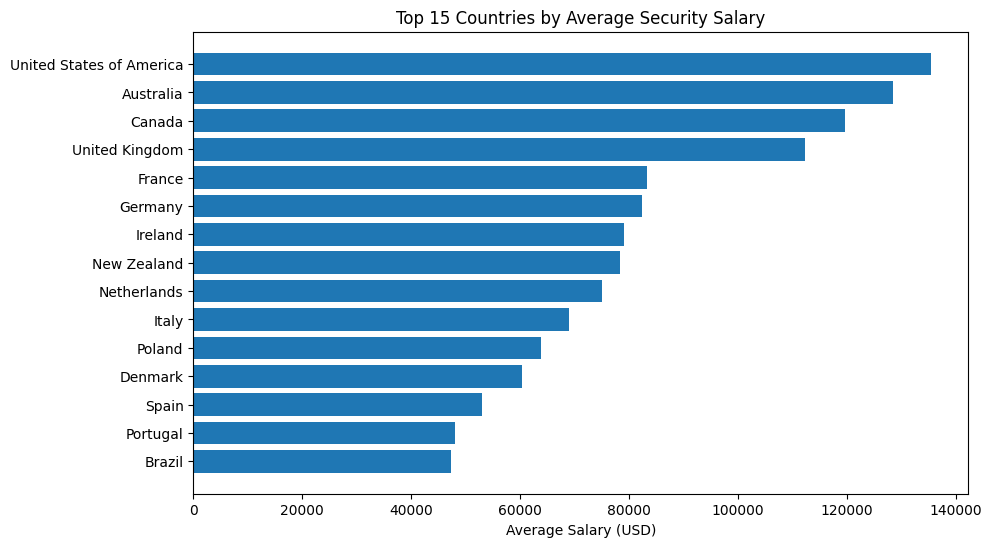

In [13]:
country_salary = (df.groupby("country_name")["salary_in_usd"].agg(avg_salary_usd="mean",count="count").reset_index())
country_salary = country_salary[country_salary["count"] >= 5]

top_countries = country_salary.sort_values(by="avg_salary_usd", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_countries["country_name"], top_countries["avg_salary_usd"])
plt.xlabel("Average Salary (USD)")
plt.title("Top 15 Countries by Average Security Salary")
plt.gca().invert_yaxis()
plt.show()

Analysis indicates that the United States leads in offering the highest salaries for cybersecurity positions.

<h3>Let us examine the average salary by continent.</h3>

In [14]:
country_to_continent = {
    # Europe
    "Germany": "Europe","Cyprus": "Europe","Bosnia and Herzegovina": "Europe","United Kingdom": "Europe","Spain": "Europe","Netherlands": "Europe",
    "Switzerland": "Europe","Denmark": "Europe","France": "Europe","Italy": "Europe","Greece": "Europe","Romania": "Europe","Åland Islands": "Europe",
    "Slovenia": "Europe","Croatia": "Europe","Sweden": "Europe","Hungary": "Europe","Ireland": "Europe","Norway": "Europe","Poland": "Europe","Portugal": "Europe",
    "Czech Republic": "Europe","Estonia": "Europe","Serbia": "Europe","Belgium": "Europe","Austria": "Europe","Luxembourg": "Europe",

    # North America
    "United States of America": "North America","Canada": "North America","Mexico": "North America","United States Minor Outlying Islands": "North America",

    # South America
    "Brazil": "South America","Chile": "South America","Argentina": "South America",

    # Asia
    "India": "Asia","Singapore": "Asia","United Arab Emirates": "Asia","Japan": "Asia","Azerbaijan": "Asia","Israel": "Asia","Pakistan": "Asia",
    "Indonesia": "Asia","Taiwan": "Asia","Vietnam": "Asia","Saudi Arabia": "Asia","Afghanistan": "Asia","Turkey": "Asia",

    # Africa
    "Botswana": "Africa","Algeria": "Africa","Ethiopia": "Africa","Kenya": "Africa","South Africa": "Africa","Egypt": "Africa",

    # Oceania
    "Australia": "Oceania","New Zealand": "Oceania",
   
    #  Others
    "Antarctica": "Antarctica", "Russian Federation": "Europe / Asia"  
}

# Assign each country to its respective continent based on the dictionary.
df["continent"] = df["country_name"].map(country_to_continent)

# average salary by continent
continent_salary = (df.groupby("continent")["salary_in_usd"].agg(avg_salary_usd="mean", count="count").reset_index())

# Remove continets with few countries
continent_salary = continent_salary[continent_salary["count"] >= 5]

# Sort by highest avg_salary
continent_salary = continent_salary.sort_values(by="avg_salary_usd", ascending=False)

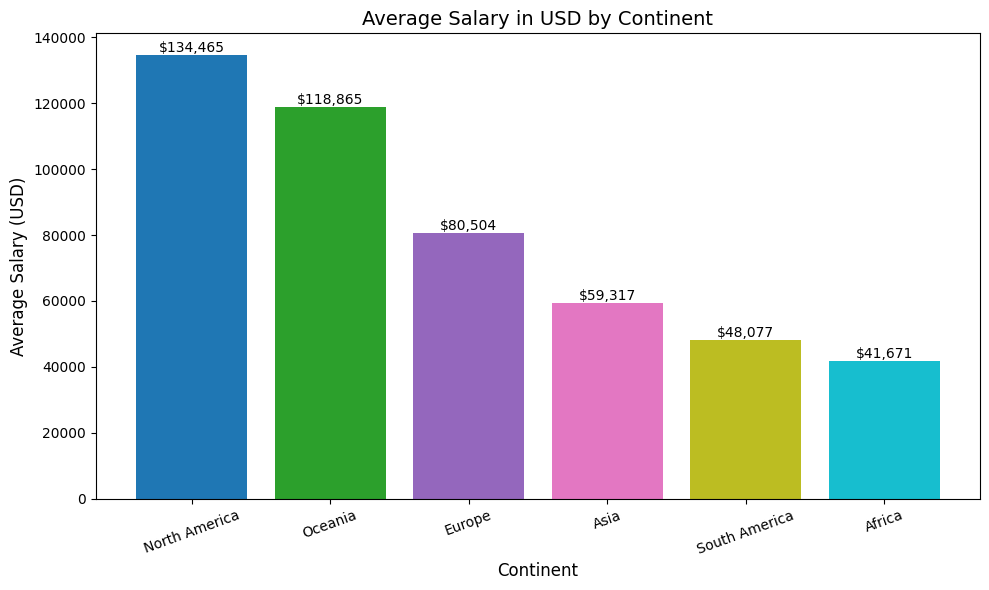

In [15]:
colors = plt.cm.tab10(np.linspace(0, 1, len(continent_salary))) 

plt.figure(figsize=(10, 6))
bars = plt.bar(continent_salary["continent"], continent_salary["avg_salary_usd"], color=colors)
plt.title("Average Salary in USD by Continent", fontsize=14)
plt.xlabel("Continent", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.xticks(rotation=20)
# Add salary labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Based on the output, salary distributions can be analyzed to infer relative cost-of-living considerations and to identify high-paying employers by region; the results indicate that North America offers the highest salary levels for security-related job roles.

<h3>Analyzing security jobs</h3>

In [16]:
## Check top 15 high paying security job titles

top_jobs = (df.groupby("job_title").agg(avg_salary=("salary_in_usd", "mean")).reset_index()
      .sort_values(by="avg_salary", ascending=False).head(15))

top_jobs

,job_title,avg_salary
1,Application Security Architect,315000.000000
79,Staff Security Engineer,295000.000000
83,Threat Intelligence Response Analyst,260000.000000
59,Principal Application Security Engineer,237000.000000
77,Software Security Engineer,235540.000000
44,Information Security Compliance Manager,230000.000000
24,Detection Engineer,225538.733333
70,Security Incident Response Engineer,205666.666667
33,IAM Engineer,198333.333333
32,Head of Security,194741.833333


Above are the top 15 highest-paying roles in the cybersecurity field, with Application Security Architect being the highest-paid position. However, these job titles may not be applicable across all organizations, as compensation is influenced by factors such as company size. Larger organizations particularly in sectors like e-commerce, banks or technology tend to require these specialized security roles to strengthen the company’s overall security posture.

<h3>Average Salary by Job Category</h3>

In [17]:
# Setting job categories
def job_categories(title):
    title = title.lower()
    if "engineer" in title:
        return "Engineer"
    elif "specialist" in title:
        return "Specialist"
    elif "manager" in title or "head" in title or "director" in title or "chief" in title:
        return "Manager"
    elif "consultant" in title:
        return "Consultant"
    elif "analyst" in title:
        return "Analyst"
    elif "architect" in title:
        return "Architect"
    elif "hacker" in title or "offensive" in title:
        return "Hacker"
    elif "researcher" in title:
        return "Researcher"
    elif "officer" in title:
        return "Officer"
    elif "lead" in title:
        return "Lead"
    elif "hunter" in title or "hunting" in title:
        return "Hunter"
    elif "tester" in title or "testing" in title:
        return "Tester"
    else:
        return "Other"

# Categorize job titles
df["job_category"] = df["job_title"].apply(job_categories)

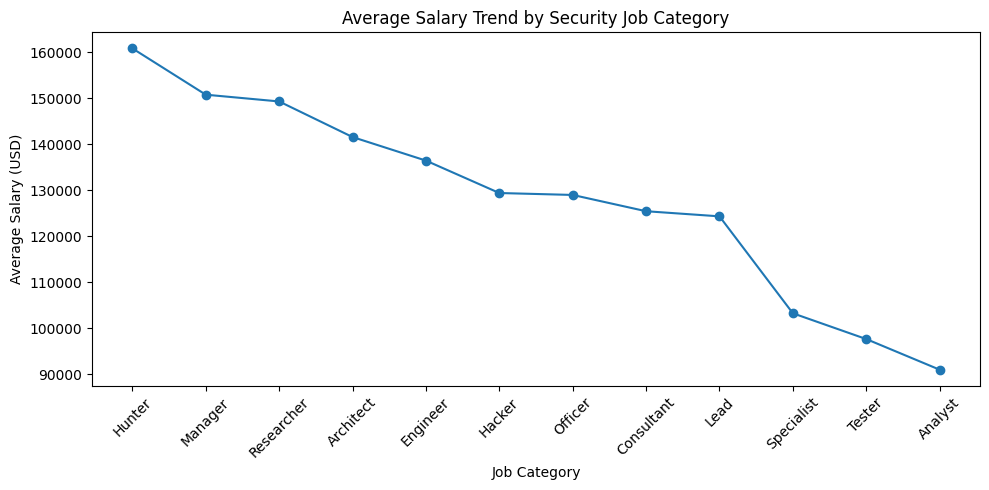

In [18]:
### Average Salary on each job category

salary_by_category = (df.groupby("job_category")["salary_in_usd"].mean().reset_index().sort_values(by="salary_in_usd", ascending=False))

plt.figure(figsize=(10, 5))
plt.plot(salary_by_category["job_category"], salary_by_category["salary_in_usd"], marker="o")
plt.xlabel("Job Category")
plt.ylabel("Average Salary (USD)")
plt.title("Average Salary Trend by Security Job Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This analysis of cybersecurity salaries using the [Cyber_salaries](https://www.kaggle.com/datasets/whenamancodes/infoseccyber-security-salaries/data) dataset provides insights into which security roles to prioritize, given the wide variety of job titles. It also allows professionals to target positions within specific companies and countries while understanding the associated average compensation. Additionally, cybersecurity professionals can leverage experience to increase their marketability, which typically translates to higher salaries.

# Data Cleaning

In [19]:
# Check for duplicates and drop them
df.duplicated().sum()

np.int64(115)

In [20]:
# Drop duplicates 
df = df.drop_duplicates()

## Encoding Categorical Columns

In [21]:
# encode categorical columns by using pandas onehot encodind "get_dummies()"
df = pd.get_dummies(df, drop_first = True)

## Handling Outliers

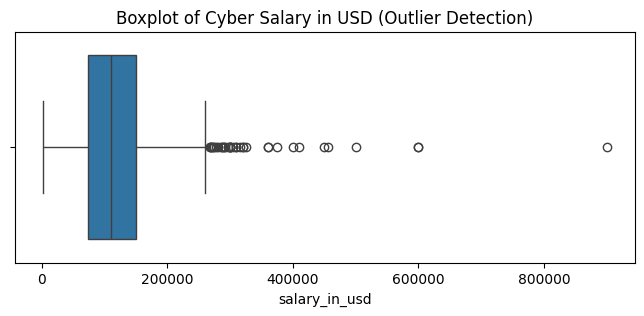

In [22]:
# Check outliers on one numerical column "salary_in_usd"
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["salary_in_usd"])
plt.title("Boxplot of Cyber Salary in USD (Outlier Detection)")
plt.show()

The boxplot indicates the presence of outliers, with some representing unusually high salaries in USD. But this indicates presence of outliers on other numerical columns.

In [23]:
# Removing Outliers by using Interquantile Range (IQR)
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter rows without outliers (based only on numeric columns)
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

## Splitting Data {Train_set, Test_set}

In [24]:
X =  df.drop("salary_in_usd", axis=1)
y = np.log1p(df["salary_in_usd"]) # Applying log transform to target variable since its right-skewed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Data Scaling 

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# Modeling and Evaluation

## RandomForestRegressor

In [26]:
rf = RandomForestRegressor(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1)
# n_estimators is 400 since our dataset is small
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

RMSE: 0.3131703612500973
MAE: 0.07128225492956079
R2 Score: 0.7861104319373355


## GradientBoostingRegressor

In [27]:
gbr = GradientBoostingRegressor(n_estimators=600, learning_rate=0.04, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, gbr_pred)))
print("MAE:", mean_absolute_error(y_test, gbr_pred))
print("R2 Score:", r2_score(y_test, gbr_pred))

RMSE: 0.26328749148630776
MAE: 0.055555109187374614
R2 Score: 0.8488219461282718


## XGBRegressor

In [28]:
xgb = XGBRegressor(n_estimator=900, learning_rate=0.03, max_depth=6, subsample=0.85, colsample_bytree=0.85, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("R2 Score:", r2_score(y_test, xgb_pred))

RMSE: 0.3508653280130229
MAE: 0.1706428485043166
R2 Score: 0.7315216903007314


# Hyperparameter Tuning

In [29]:
param_grid = {
    'n_estimators': [200, 400, 600, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    n_iter=20, # number of trials to perform random parameter combinations
    cv=5, # prevents overfitting
    scoring='neg_root_mean_squared_error', # minimize RMSE
    n_jobs=-1 #use all CPU cores
)

search.fit(X_train, y_train)

best_gbr = search.best_estimator_

pred = best_gbr.predict(X_test)
print("Best Parameters:", search.best_params_)
print("RMSE Tuned:", np.sqrt(mean_squared_error(y_test, pred)))
print("MAE Tuned:", mean_absolute_error(y_test, pred))

Best Parameters: {'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.03}
RMSE Tuned: 0.2450535218039871
MAE Tuned: 0.052838377963121345


In [30]:
# Final prediction on ensemble Models used
final_pred = (rf_pred + gbr_pred + xgb_pred) / 3

print("ENSEMBLE RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))
print("ENSEMBLE MAE:", mean_absolute_error(y_test, final_pred))
print("ENSEMBLE R2 Score:", r2_score(y_test, final_pred))

ENSEMBLE RMSE: 0.29251574624855703
ENSEMBLE MAE: 0.07655161865393151
ENSEMBLE R2 Score: 0.8133934878825504


In [31]:
# Return preds to normal values since they're transformed (log transform)

final_pred = np.expm1(final_pred)
y_test_normal = np.expm1(y_test)

In [32]:
y_test_normal

200    207800.0
906     85000.0
590    125000.0
281     80000.0
815    120000.0
         ...   
474    120000.0
70      28890.0
505    135000.0
774     50000.0
528    150000.0
Name: salary_in_usd, Length: 231, dtype: float64

Among the three evaluated models, **_GradientBoostingRegressor_** achieved the best performance, producing the lowest RMSE and MAE and the highest R2 Score, indicating strong predictive capability and good generalization. Hyperparameter tuning further improved the Gradient Boosting model, slightly reducing prediction errors and confirming that optimized parameters enhance model accuracy. Therefore, the tuned **_GradientBoostingRegressor_** was selected as the final and most reliable model for this prediction task due to its superior overall performance compared to _Random Forest_ and _XGBoost_.